# CuRIOS FITS Imaging - Version 2.8

This notebook demonstrates the standard workflow for analyzing a CuRIOS FITS image.

Workflow:

1. Configure analysis parameters
2. Select an observing folder and image
3. Analyze the image
4. Display the standard report
5. (Optional) Run additional diagnostics

For advanced examples, see the notebooks in the `examples/` directory.

In [1]:
from fits_imaging.config import ImagingConfig
from fits_imaging.analysis import analyze_image
from fits_imaging.session import ImagingSession

config = ImagingConfig()
session = ImagingSession(config.data_root)

In [2]:
config = ImagingConfig()

# Optional display choices
config.colormap = "viridis"
config.contrast_method = "sigma"
config.contrast_sigma_low = 1.0
config.contrast_sigma_high = 5.0
config.stretch = "linear"

config

ImagingConfig(data_root=PosixPath('/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories'), zero_mag_counts=115000000, pixel_arcsec=1.24, threshold_sigma=5.0, max_peaks=1000, peak_separation=10.0, peak_sharp=0.2, fit_method='gaussian', contrast_method='sigma', contrast_percentiles=(1.0, 99.8), contrast_sigma_low=1.0, contrast_sigma_high=5.0, stretch='linear', colormap='viridis', invert_colormap=False, invert_gray=False, histogram_max_points=2000000, histogram_bins=200, stats_region='center_fraction', stats_center_fraction=0.5, stats_center_pixels=2000, source_region='center_fraction', source_region_fraction=0.5)

In [3]:
session = ImagingSession()
session.status()

Data root:      /Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories
Current folder: /Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories/Patio-0629
Last image:     /Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories/Patio-0629/Neptune_2026-06-29_10.40.37_CuED-0.fits


In [4]:
results = session.analyze(config)
#results


File#       File
----------------------------------------------------------------------
    0       Altair-Bahtinov_2026-06-29_08.15.59_CuED-0.fits
    1       Altair-Bahtinov_2026-06-29_08.15.59_CuED_0_sum.fits
    2       Altair-Bahtinov_2026-06-29_08.21.48_CuED-0.fits
    3       Altair-Bahtinov_2026-06-29_08.26.49_CuED-0.fits
    4       M15_2026-06-29_10.20.58_CuED_10_sum.fits
    5       M57_2026-06-29_10.06.46_CuED_5_sum.fits
    6       M71_2026-06-29_10.11.32_CuED_10_sum.fits
    7       Neptune_2026-06-29_10.30.12_CuED-0.fits
    8       Neptune_2026-06-29_10.30.12_CuED_4_sum.fits
    9       Neptune_2026-06-29_10.40.37_CuED-0.fits
   10       Neptune_2026-06-29_10.40.37_CuED_4_sum.fits
   11       Polaris_2026-06-29_08.56.03_CuED_5_sum.fits
   12       Polaris_2026-06-29_08.59.05_CuED-0.fits
   13       Saturn_2026-06-29_10.45.04_CuED-0.fits
   14       Saturn_2026-06-29_10.45.04_CuED_9_sum.fits
   15       Vega-Bahtinov_2026-06-29_09.26.41_CuED-0.fits
   16       VegaBC_20

Enter file number to analyze:  9


Neptune  9576 x 6380  Apx60-CuED  2.513 sec
RAH:   0.283  Dec:   0.348  PA: 315.64  PA2:  44.36  Alt:    31.5  Az:   117.8
Mean: 302.5  Median: 301.0  Std: 29.8  Min: 91.0  Max: 37624.0
Found 98 peaks in 2.88 sec

Source statistics:
{'nstars': 98, 'median_fwhm': 5.722994804382324, 'median_flux': 10102.0, 'brightest_flux': 412565.0}

Selected-region source statistics:
{'nstars': 26, 'median_fwhm': 5.5563459396362305, 'median_flux': 12822.0, 'brightest_flux': 155481.0}


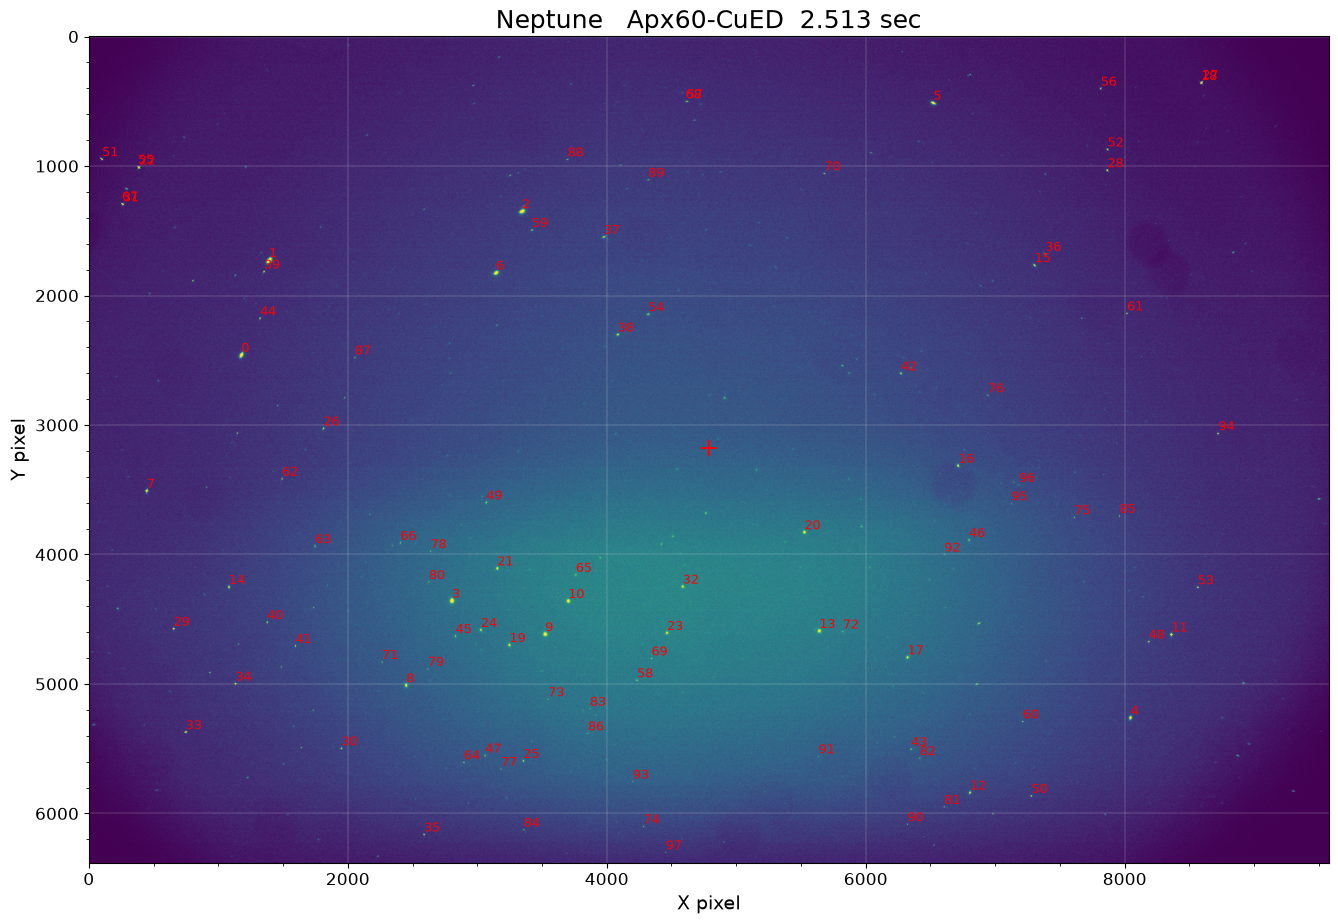


Peak#        X        Y        Area       sx      sy        Flux      Mag
------------------------------------------------------------------------------
    0   1177.55   2458.14    613561.6    3.93    3.46    412565.0    7.113
    1   1392.36   1726.46    408838.0    4.29    4.66    221865.0    7.787
    2   3345.88   1348.74    223432.6    3.11    2.13    189235.0    7.960
    3   2804.54   4357.14    167160.5    1.38    2.54    155481.0    8.173
    4   8045.11   5260.66    213413.9    3.72    3.00    151463.0    8.201
    5   6522.11    511.26    189935.2    3.53    3.28    138421.0    8.299
    6   3144.93   1824.45    147813.7    2.67    2.34    137781.0    8.304
    7    447.36   3507.63    172392.4    5.16    3.04     89506.0    8.773
    8   2450.95   5010.83     86552.6    1.62    2.08     86442.0    8.810
    9   3524.00   4615.77     75465.9    1.81    2.45     77563.0    8.928
   10   3702.84   4360.11     73996.7    2.28    2.72     69531.0    9.047
   11   8360.88   461

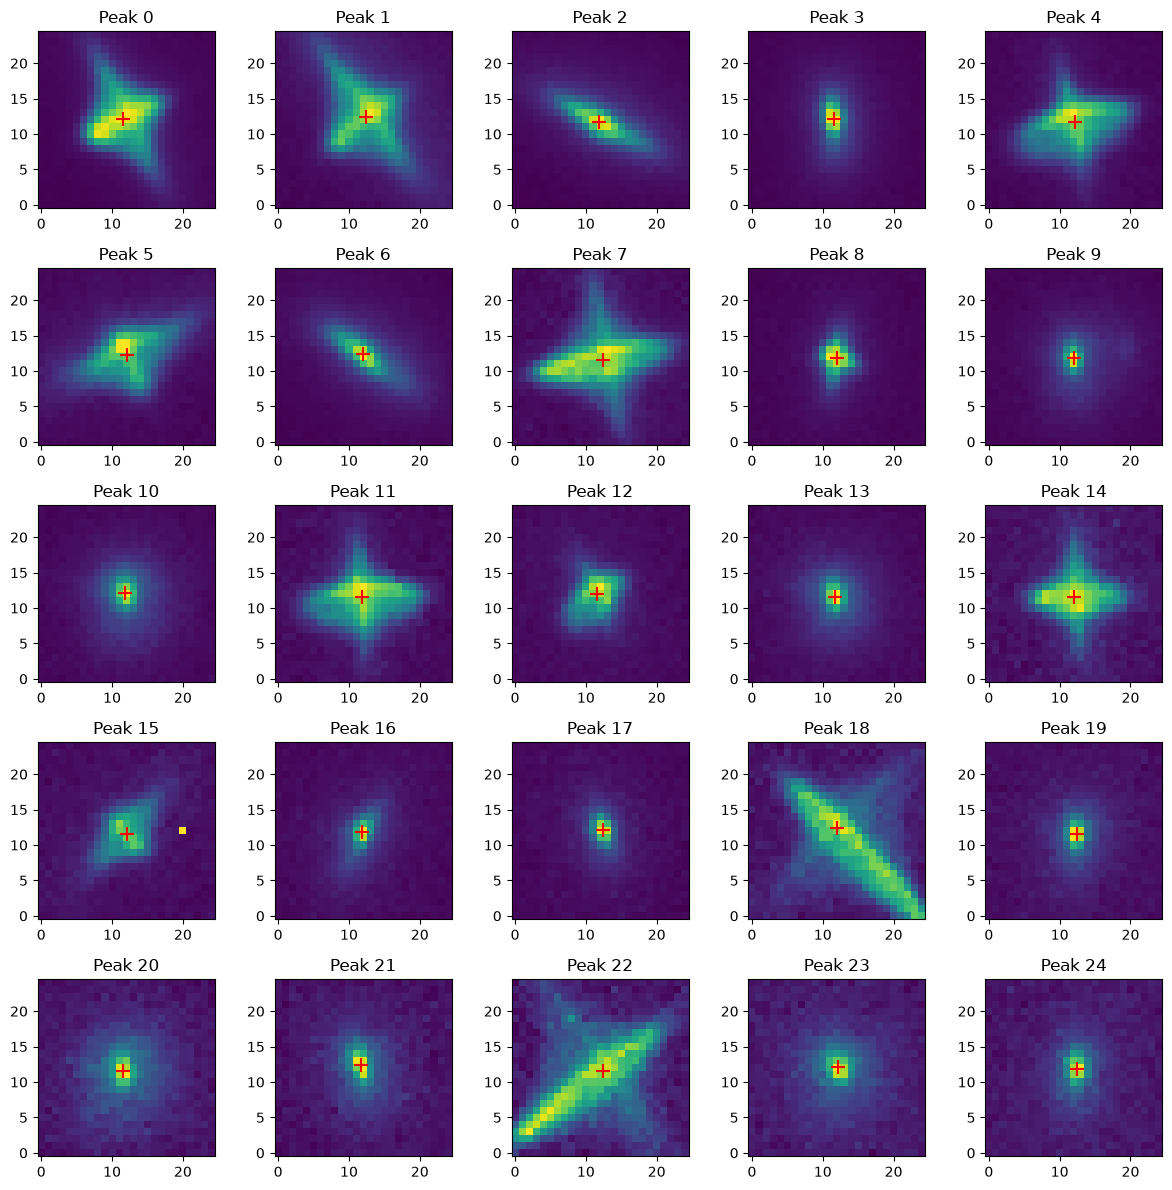

In [5]:
results.report(
    config=config,
    show_summary=True,
    show_image=True,
    show_table=True,
    show_cutouts=True,
    show_histogram=False,
    show_statistics=True,
)

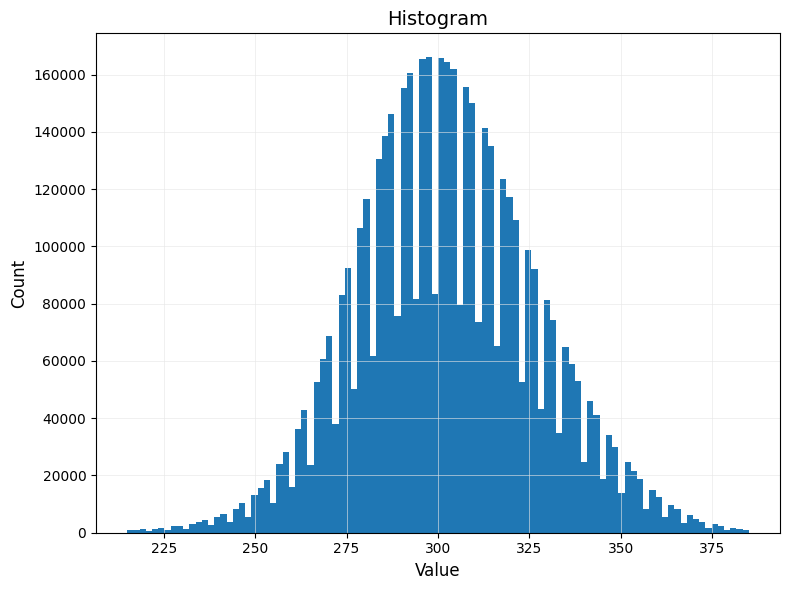

In [13]:
results.plot_histogram(config=config)
plt.show()

In [6]:
results.source_statistics()

{'nstars': 98,
 'median_fwhm': 5.722994804382324,
 'median_flux': 10102.0,
 'brightest_flux': 412565.0}

In [1]:
import sys
import os

print("Version:", sys.version)
print("Executable:", sys.executable)
print("Prefix:", sys.prefix)

Version: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 21.0.0 (clang-2100.0.123.102)]
Executable: /Users/svwbeckwith/Dropbox/CuRIOS/Software/Python/curios-fits-imaging/.venv312/bin/python
Prefix: /Users/svwbeckwith/Dropbox/CuRIOS/Software/Python/curios-fits-imaging/.venv312
